In [1]:
import math

In [2]:
from math import*

In [3]:
import numpy as np

In [4]:
import pandas as pd

In [5]:
import polars as pl

In [6]:
import pyarrow.parquet as pq

In [7]:
import matplotlib.pyplot as plt

In [8]:
def delta_p_df(df):
    return df.diff(axis=1).iloc[:, 1:]

In [9]:
def convert_to_matrix(subset_data):
    return subset_data.to_numpy()

In [10]:
def covariance_to_correlation(cov_matrix):
    variances = np.diag(cov_matrix)
    std_deviations = np.sqrt(variances)
    std_outer = np.outer(std_deviations, std_deviations)
    correlation_matrix = cov_matrix/std_outer
    return correlation_matrix

In [11]:
def split_column_name(col_name):
    parts = [int(x) for x in col_name.split("_")]
    return (parts[2],parts[1],parts[0])

def subset_site_cols_organized(dataframe, location):
    '''takes in dataframe as a table and a location number as a string and returns the subset'''
    cols_selected = [
        col for col in dataframe.columns
        if col == "1_0_1" or col.split("_")[0] == location
    ]
    subset_site = dataframe[cols_selected]

    sorted_columns = sorted(subset_site.columns, key=split_column_name)
    subset_site_organized = subset_site[sorted_columns]
    
    return subset_site_organized

In [12]:
seedmix = pd.read_csv("seedmix_hapfire_allele_frequency_random_switch_fixrm.csv", nrows=10000)

In [13]:
master_df = pd.read_csv("PHASE_1_2_COMBINED_hapFIRE_allele_frequency_random_switch_fixrm.csv", nrows=10000)

In [14]:
master_df.insert(loc=0, column="1_0_1", value = seedmix["X3"])

In [15]:
full_seedmix = pd.read_csv("seedmix_hapfire_allele_frequency_random_switch_fixrm.csv", usecols=['X3'])

In [16]:
#lazy_df = pl.scan_csv("PHASE_1_2_COMBINED_hapFIRE_allele_frequency_random_switch_fixrm.csv", null_values='NA').sink_parquet('output.parquet', compression='zstd')

In [47]:
def lazy_load(file_path, df_master, location, replicate):
    '''lazy load the columns needed'''

    cols_selected = [
        col for col in df_master.columns
        if col != '1_0_1' and col.split("_")[0] == location and col.split("_")[-1] == replicate
    ]

    cols_sorted = sorted(cols_selected, key=split_column_name)

    df = pd.read_parquet(file_path, columns=cols_sorted)
    
    df.insert(0, '1_0_1', full_seedmix['X3'])
    
    return df

In [18]:
def array_the_reps(master_matrix_df):
    return sorted(list(set(int(col.split('_')[2]) for col in master_matrix_df.columns)))

In [23]:
sites = sorted(list(set(int(col.split('_')[0]) for col in master_df.columns)))

In [19]:
def plot_it(df, corr_matrix, main_labels, site_name, replicate):
    %matplotlib inline
    
    plt.figure(figsize=(10,6))

    new_list = []
    for s in range(len(main_labels)):
        new_list.append(main_labels[s:])
    print(new_list)

    rows_generation = [
            row.split('_')[1] for row in df.index
        ]
    
    for i in range(len(corr_matrix)-1):
        row_elements = corr_matrix[i,i+1:]
        labels = new_list[i]
        int_labels = [int(x) for x in labels]

        current_gen = rows_generation[i]
        
        plt.plot(int_labels, row_elements, marker='o', label=f'Generation{current_gen}')
        print('x-axis labels =', labels)

    plt.title('Correlation for Site '+ site_name + ', Replicate ' + replicate)
    plt.xlabel('Generation')
    plt.ylabel('Correlation Value')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
    return plt.show()

In [20]:
def find_the_plots_for_the_site_lazy_df(file_path, df_master, site):
    #get the reps from master_df
    site_subset = subset_site_cols_organized(df_master, site)
    reps = array_the_reps(site_subset)
    
    for r in reps:
        subset_df = lazy_load(file_path, df_master, site, str(r))
        subset_df_cov = delta_p_df(subset_df).cov()
        extract_year = [
            col.split('_')[1] for col in subset_df_cov.columns
        ]
        print(extract_year)
        correlation = covariance_to_correlation(subset_df_cov)
        plot_it(correlation, convert_to_matrix(correlation), extract_year[1:], site, str(r))
    return 

In [21]:
def plot_em_together(df, corr_matrix, main_labels, site_name, replicate, ax):
    
    new_list = []
    for s in range(len(main_labels)):
        new_list.append(main_labels[s:])
    print(new_list)

    rows_generation = [
            row.split('_')[1] for row in df.index
        ]
    
    for i in range(len(corr_matrix)-1):
        row_elements = corr_matrix[i,i+1:]
        labels = new_list[i]
        int_labels = [int(x) for x in labels]
        
        current_gen = rows_generation[i]
        
        ax.plot(int_labels, row_elements, marker='o', label=f'Generation{current_gen}')
        print('x-axis labels =', labels)

    ax.set_title(f'Correlation for Site {site_name}, Replicate {replicate}', fontsize=10)
    ax.set_xlabel('Generation', fontsize=8)
    ax.set_ylabel('Correlation', fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left', fontsize=6)

In [38]:
def find_the_plots_save_file_lazy_df(file_path, df_master, site):
    site_subset = subset_site_cols_organized(df_master, site)
    reps = array_the_reps(site_subset)
    
    num_cols = 3
    num_rows = math.ceil(len(reps)/num_cols)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4*num_rows))
    axes_flat = axes.flatten() if len(reps)>1 else [axes]
    
    for idx, r in enumerate(reps):
        current_ax = axes_flat[idx]

        subset_df = lazy_load(file_path, df_master, site, str(r))
        subset_df_cov = delta_p_df(subset_df).cov()
        extract_year = [
            col.split('_')[1] for col in subset_df_cov.columns
        ]
        correlation = covariance_to_correlation(subset_df_cov)
        
        plot_em_together(correlation, convert_to_matrix(correlation), extract_year[1:], site, str(r), current_ax)

    for missing_idx in range(len(reps), len(axes_flat)):
        fig.delaxes(axes_flat[missing_idx])

    plt.tight_layout()
    plt.savefig(f'Site_{site}_all_replicates.png', bbox_inches='tight', dpi=150)
    plt.close(fig)


In [41]:
lazy_load("PHASE_1_2_COMBINED_hapFIRE_allele_frequency_random_switch_fixrm.parquet", master_df, '57', '9').head(10)

['57_1_9', '57_2_9', '57_3_9', '57_4_9', '57_5_9']


,1_0_1,57_1_9,57_2_9,57_3_9,57_4_9,57_5_9
0,0.037575,0.007708,0.007143,NaN,0.004348,0.173518
1,0.264121,0.331371,0.128107,0.002591,0.309076,0.036203
2,0.010239,0.004220,0.001903,0.000615,0.002095,0.000801
3,0.020212,0.070379,0.126246,NaN,0.005138,0.156316
4,0.067621,0.047035,0.093667,0.001183,0.197296,0.008275
5,0.912261,0.952418,0.843283,0.999083,0.985555,0.987154
6,0.052009,0.013168,0.010255,NaN,0.017660,0.174468
7,0.052009,0.013168,0.010255,NaN,0.017660,0.174468
8,0.045402,0.034362,0.004763,NaN,0.002979,0.001664
9,0.899678,0.862592,0.775155,0.998817,0.795294,0.834589


In [45]:
lazy_load("PHASE_1_2_COMBINED_hapFIRE_allele_frequency_random_switch_fixrm.parquet", master_df, '1', '1').head(10)

['1_1_1', '1_2_1', '1_3_1', '1_4_1']


,1_0_1,1_1_1,1_2_1,1_3_1,1_4_1
0,0.037575,0.045527,0.027944,0.001647,0.020583
1,0.264121,0.303972,0.382195,0.746828,0.476855
2,0.010239,0.017308,0.004543,0.000312,0.001094
3,0.020212,0.021860,0.157563,0.125082,0.010245
4,0.067621,0.046952,0.037010,0.006074,0.043030
5,0.912261,0.846852,0.889717,0.937408,0.806929
6,0.052009,0.048754,0.035094,0.002047,0.022899
7,0.052009,0.048754,0.035094,0.002047,0.022899
8,0.045402,0.029219,0.009852,0.001047,0.021496
9,0.899678,0.922220,0.790047,0.867980,0.913024


In [ ]:
#for site in sites:
  #  find_the_plots_save_file_lazy_df("PHASE_1_2_COMBINED_hapFIRE_allele_frequency_random_switch_fixrm.parquet", master_df, str(site))

In [48]:
lazy_load("PHASE_1_2_COMBINED_hapFIRE_allele_frequency_random_switch_fixrm.parquet", master_df, '57', '10').head(10)

,1_0_1,57_1_10,57_2_10,57_3_10,57_4_10,57_5_10
0,0.037575,0.003141,0.011078,0.000651,0.015255,0.000552
1,0.264121,0.154356,0.385415,0.188344,0.224807,0.261259
2,0.010239,0.003826,0.003428,0.000928,0.007167,0.000579
3,0.020212,0.017474,0.010615,0.000644,0.035416,0.002485
4,0.067621,0.218528,0.078317,0.206976,0.181699,0.002071
5,0.912261,0.892291,0.936659,0.998205,0.960385,0.995464
6,0.052009,0.004269,0.014680,0.000963,0.018699,0.000552
7,0.052009,0.004269,0.014680,0.000963,0.018699,0.000552
8,0.045402,0.001930,0.008288,0.000778,0.074530,0.000239
9,0.899678,0.741584,0.907656,0.792049,0.775715,0.995171


['1', '2', '3', '4']
[['2', '3', '4'], ['3', '4'], ['4']]
x-axis labels = ['2', '3', '4']
x-axis labels = ['3', '4']
x-axis labels = ['4']


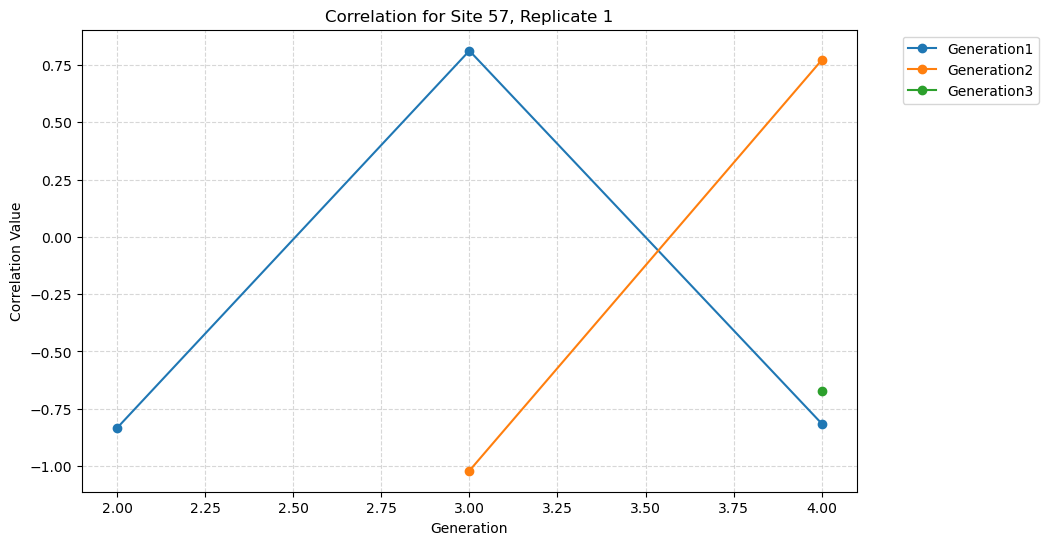

['1', '2', '3', '4']
[['2', '3', '4'], ['3', '4'], ['4']]
x-axis labels = ['2', '3', '4']
x-axis labels = ['3', '4']
x-axis labels = ['4']


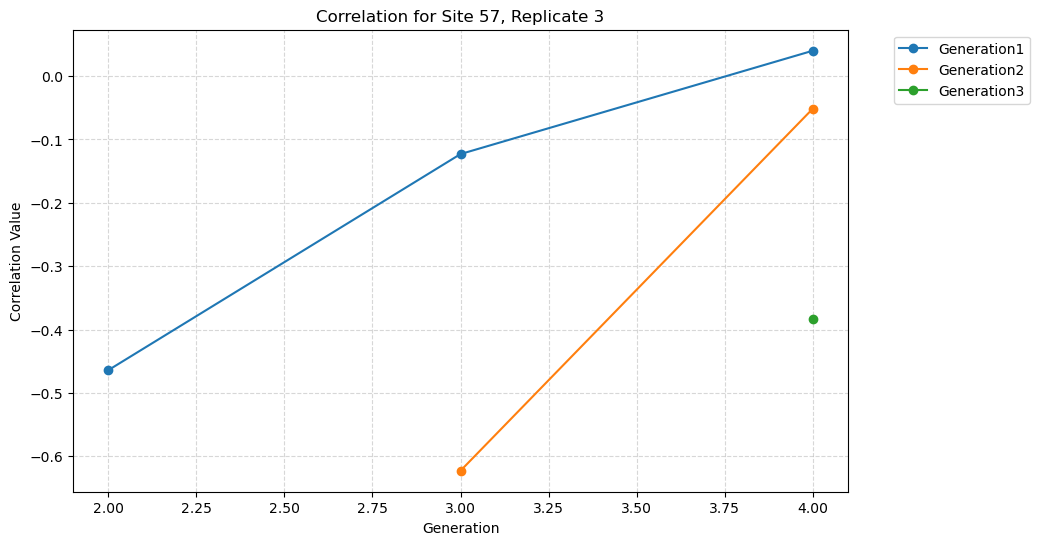

['1', '2', '3', '4', '5']
[['2', '3', '4', '5'], ['3', '4', '5'], ['4', '5'], ['5']]
x-axis labels = ['2', '3', '4', '5']
x-axis labels = ['3', '4', '5']
x-axis labels = ['4', '5']
x-axis labels = ['5']


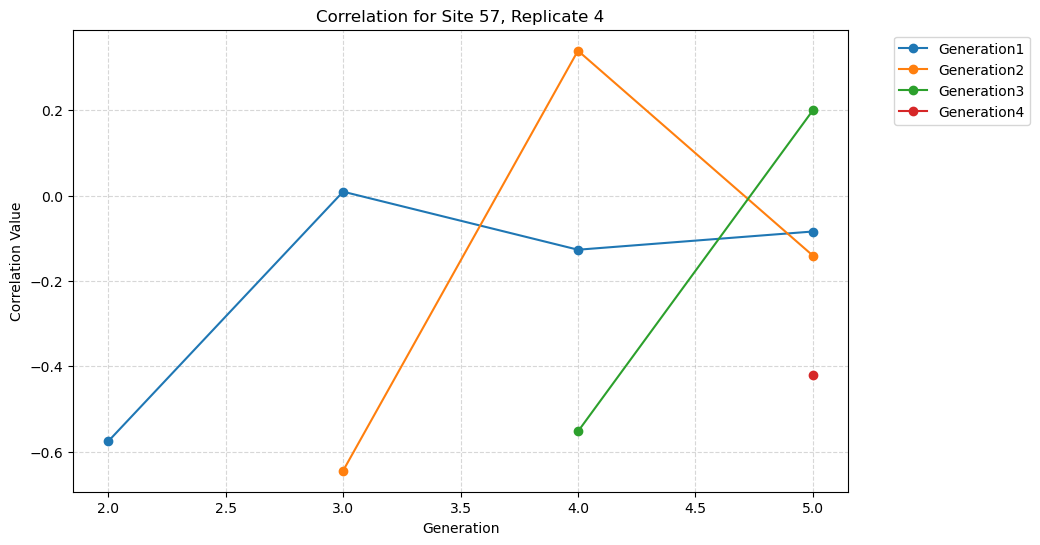

['1', '2', '3', '4']
[['2', '3', '4'], ['3', '4'], ['4']]
x-axis labels = ['2', '3', '4']
x-axis labels = ['3', '4']
x-axis labels = ['4']


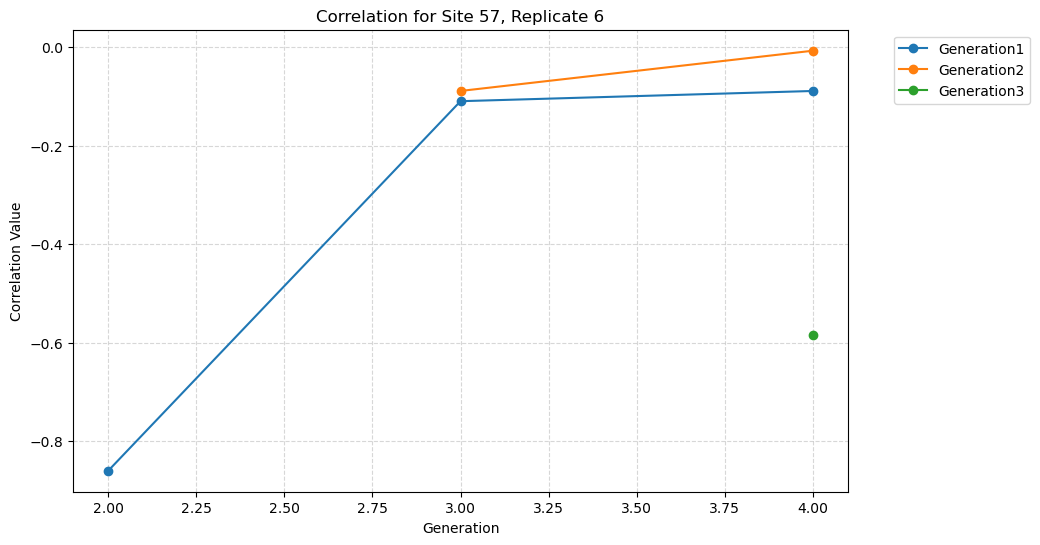

['1', '2', '3', '4', '5']
[['2', '3', '4', '5'], ['3', '4', '5'], ['4', '5'], ['5']]
x-axis labels = ['2', '3', '4', '5']
x-axis labels = ['3', '4', '5']
x-axis labels = ['4', '5']
x-axis labels = ['5']


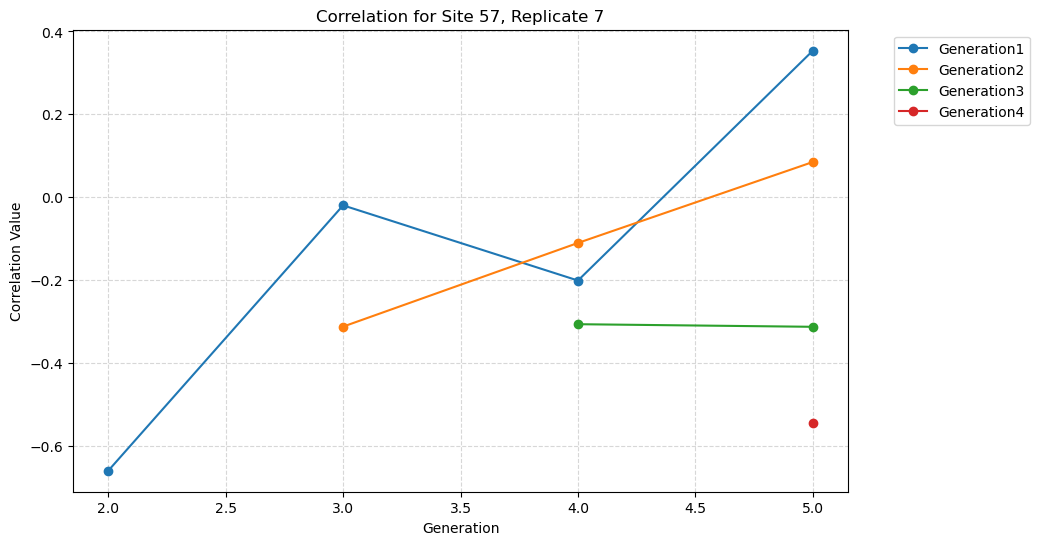

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['4']
[]


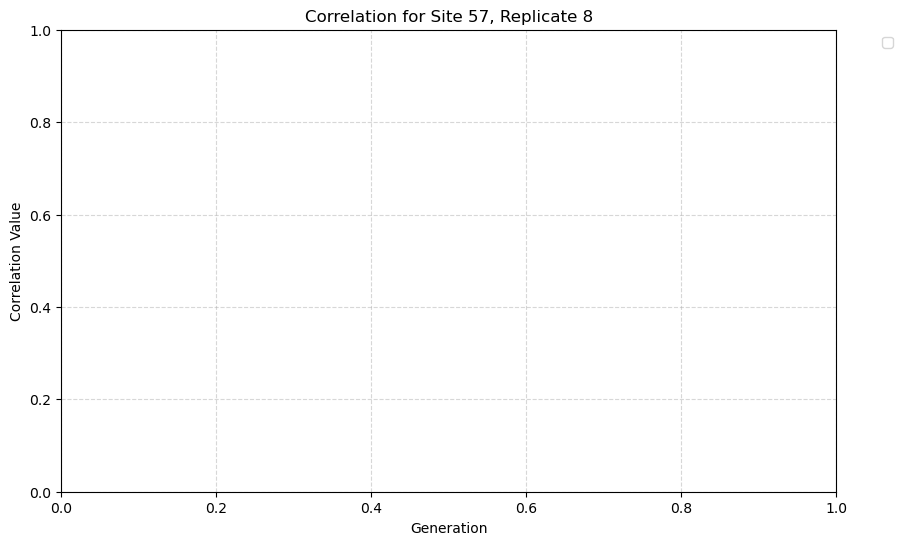

['1', '2', '3', '4', '5']
[['2', '3', '4', '5'], ['3', '4', '5'], ['4', '5'], ['5']]
x-axis labels = ['2', '3', '4', '5']
x-axis labels = ['3', '4', '5']
x-axis labels = ['4', '5']
x-axis labels = ['5']


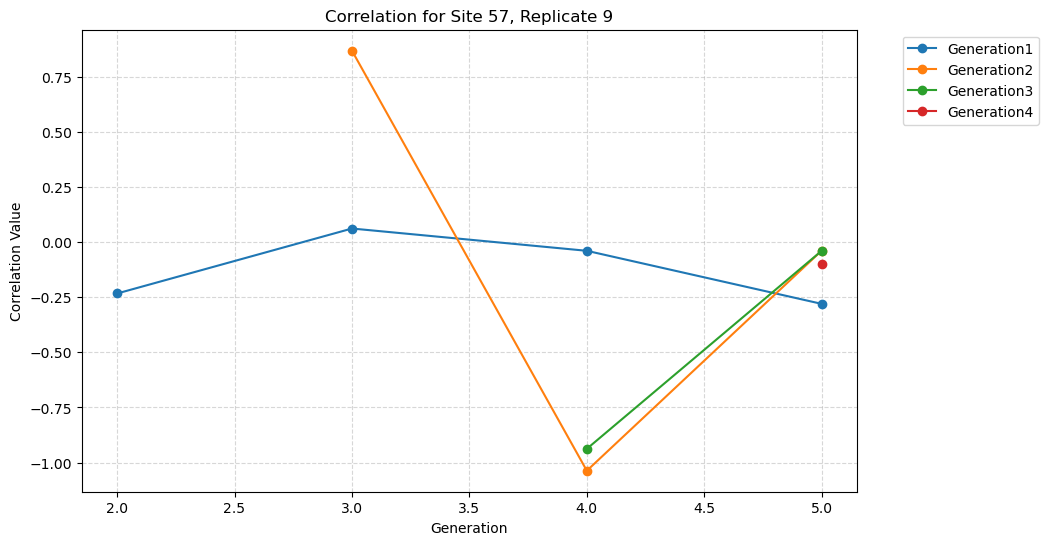

['1', '2', '3', '4', '5']
[['2', '3', '4', '5'], ['3', '4', '5'], ['4', '5'], ['5']]
x-axis labels = ['2', '3', '4', '5']
x-axis labels = ['3', '4', '5']
x-axis labels = ['4', '5']
x-axis labels = ['5']


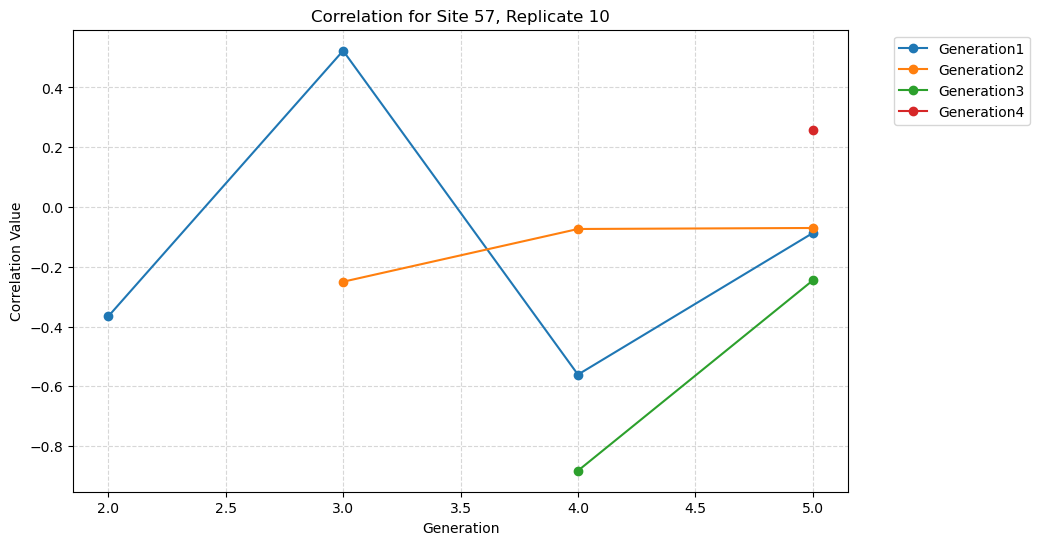

['1', '2', '3', '4']
[['2', '3', '4'], ['3', '4'], ['4']]
x-axis labels = ['2', '3', '4']
x-axis labels = ['3', '4']
x-axis labels = ['4']


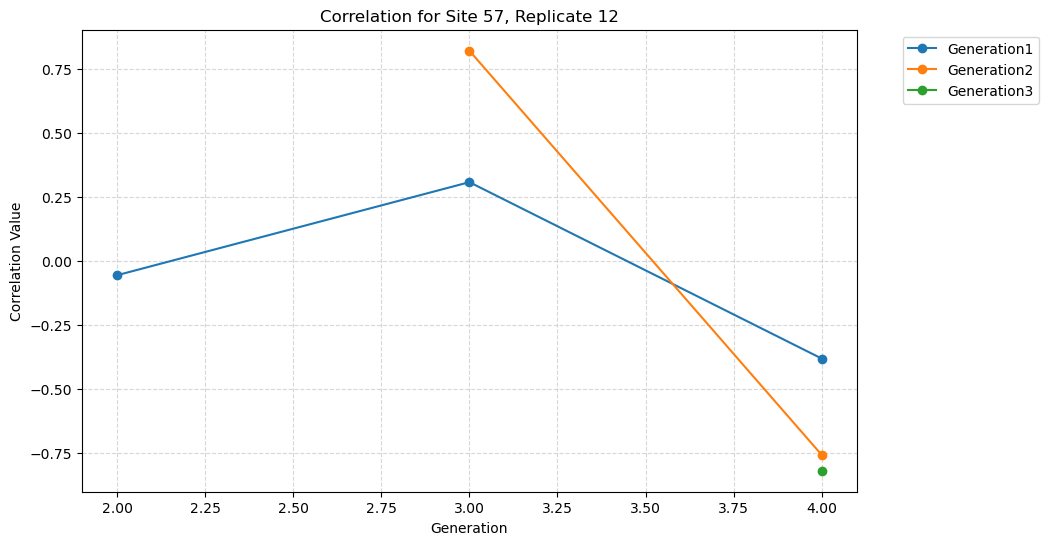

['1', '2', '3', '4', '5']
[['2', '3', '4', '5'], ['3', '4', '5'], ['4', '5'], ['5']]
x-axis labels = ['2', '3', '4', '5']
x-axis labels = ['3', '4', '5']
x-axis labels = ['4', '5']
x-axis labels = ['5']


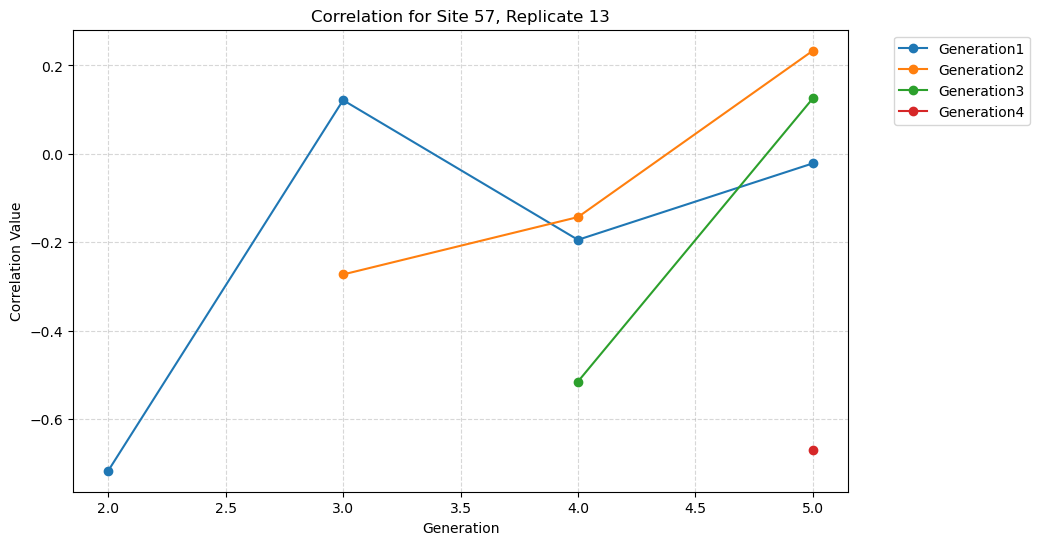

['4', '5']
[['5']]
x-axis labels = ['5']


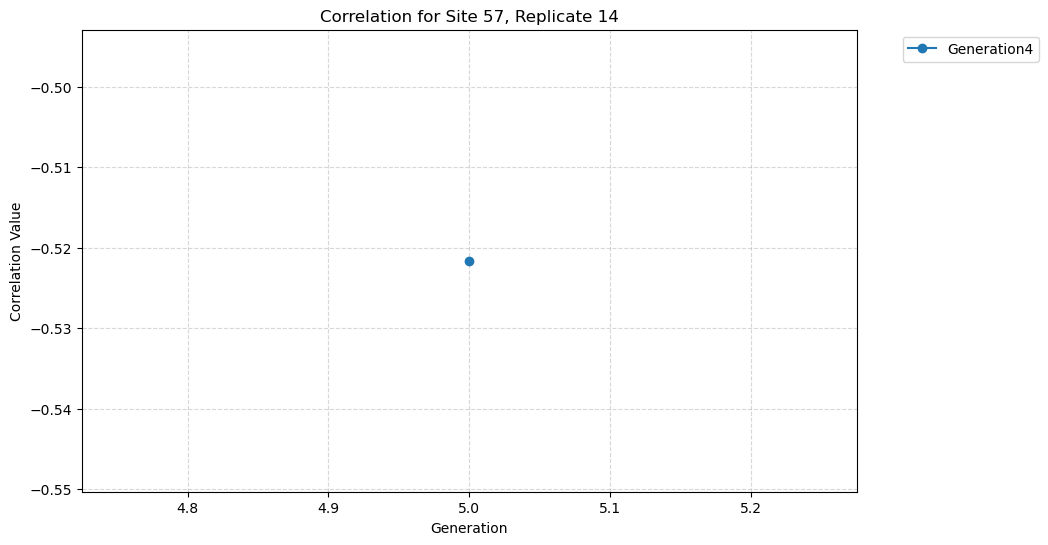

['1', '2', '3', '4']
[['2', '3', '4'], ['3', '4'], ['4']]
x-axis labels = ['2', '3', '4']
x-axis labels = ['3', '4']
x-axis labels = ['4']


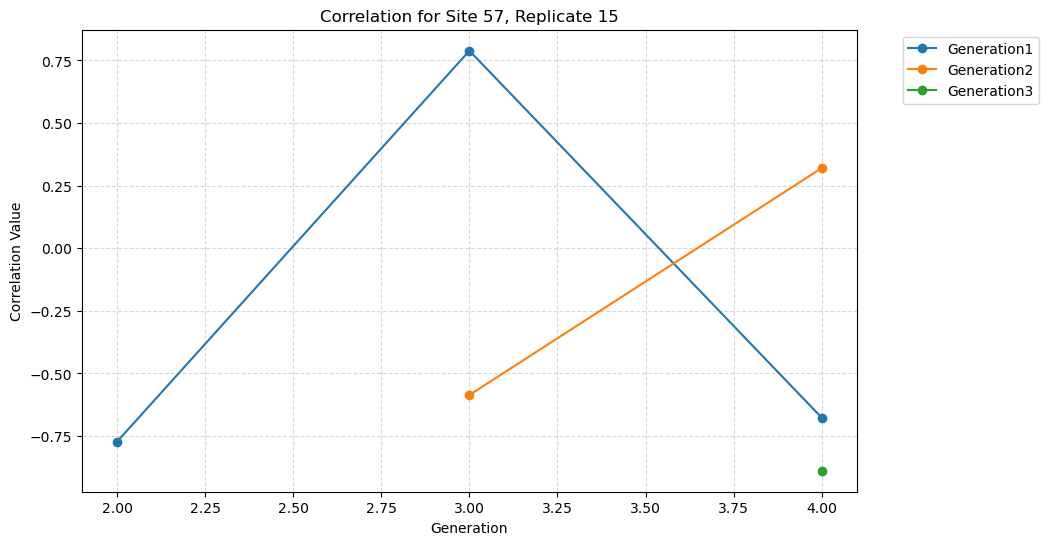

['1', '2', '3', '4', '5']
[['2', '3', '4', '5'], ['3', '4', '5'], ['4', '5'], ['5']]
x-axis labels = ['2', '3', '4', '5']
x-axis labels = ['3', '4', '5']
x-axis labels = ['4', '5']
x-axis labels = ['5']


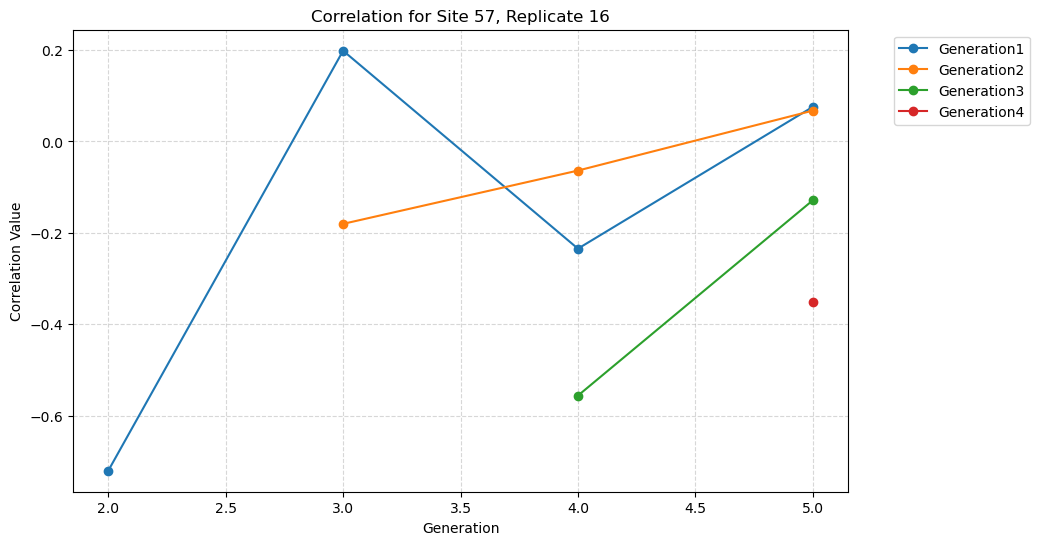

['1', '2', '3', '4', '5']
[['2', '3', '4', '5'], ['3', '4', '5'], ['4', '5'], ['5']]
x-axis labels = ['2', '3', '4', '5']
x-axis labels = ['3', '4', '5']
x-axis labels = ['4', '5']
x-axis labels = ['5']


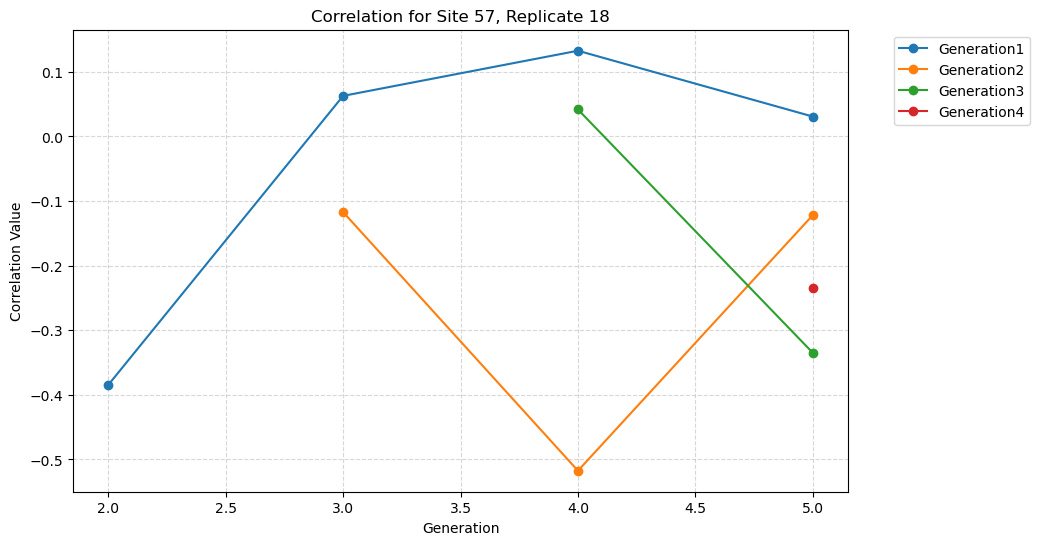

In [24]:
find_the_plots_for_the_site_lazy_df("PHASE_1_2_COMBINED_hapFIRE_allele_frequency_random_switch_fixrm.parquet", master_df, '57')

In [51]:
def find_the_cov_plots_for_the_site(file_path, df_master, site):
    #get the reps from master_df
    site_subset = subset_site_cols_organized(df_master, site)
    reps = array_the_reps(site_subset)
    
    for r in reps:
        subset_df = lazy_load(file_path, df_master, site, str(r))
        subset_df_cov = delta_p_df(subset_df).cov()
        extract_year = [
            col.split('_')[1] for col in subset_df_cov.columns
        ]
        print(extract_year)
        plot_it(subset_df_cov, convert_to_matrix(subset_df_cov), extract_year[1:], site, str(r))
    return 

['1', '2', '3', '4']
[['2', '3', '4'], ['3', '4'], ['4']]
x-axis labels = ['2', '3', '4']
x-axis labels = ['3', '4']
x-axis labels = ['4']


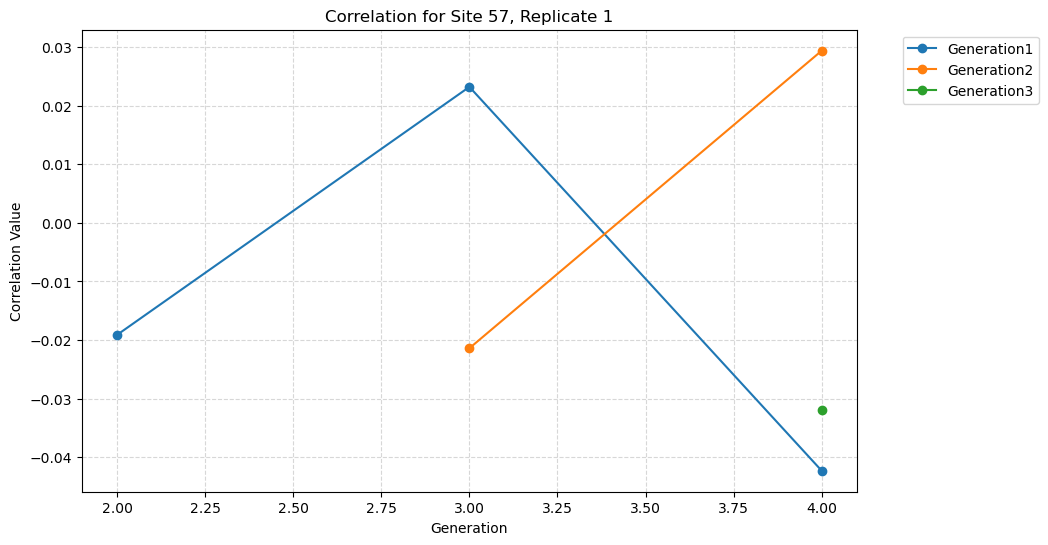

['1', '2', '3', '4']
[['2', '3', '4'], ['3', '4'], ['4']]
x-axis labels = ['2', '3', '4']
x-axis labels = ['3', '4']
x-axis labels = ['4']


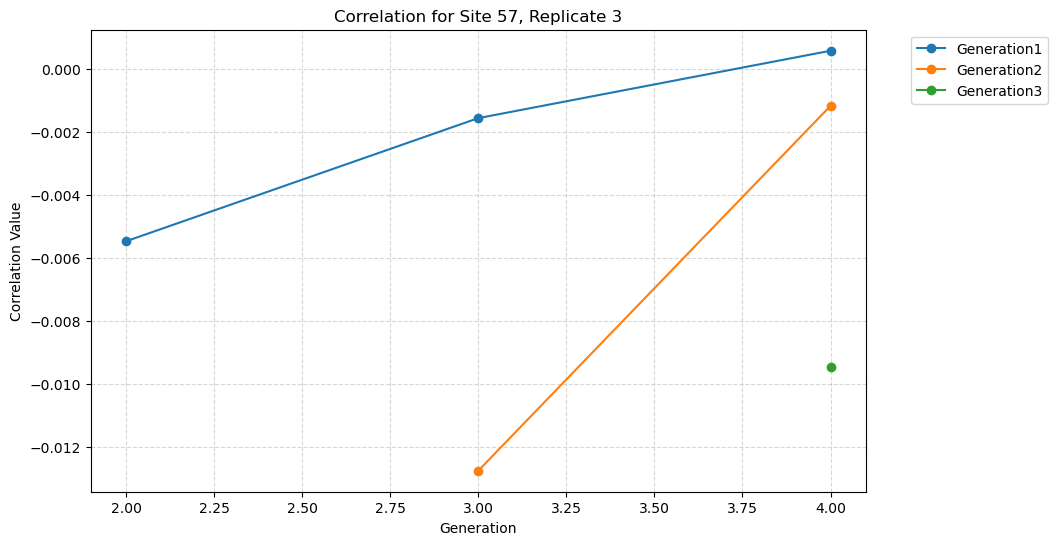

['1', '2', '3', '4', '5']
[['2', '3', '4', '5'], ['3', '4', '5'], ['4', '5'], ['5']]
x-axis labels = ['2', '3', '4', '5']
x-axis labels = ['3', '4', '5']
x-axis labels = ['4', '5']
x-axis labels = ['5']


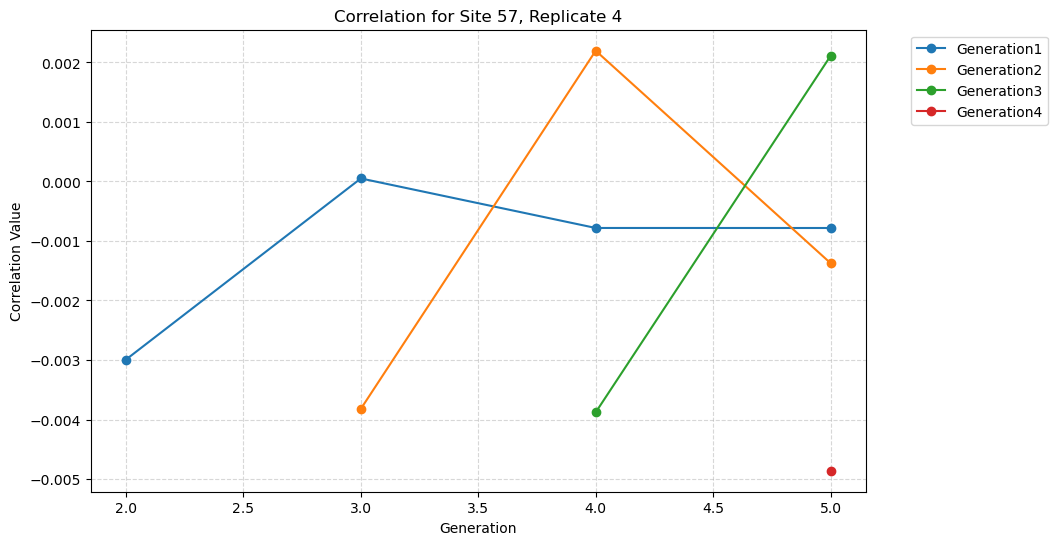

['1', '2', '3', '4']
[['2', '3', '4'], ['3', '4'], ['4']]
x-axis labels = ['2', '3', '4']
x-axis labels = ['3', '4']
x-axis labels = ['4']


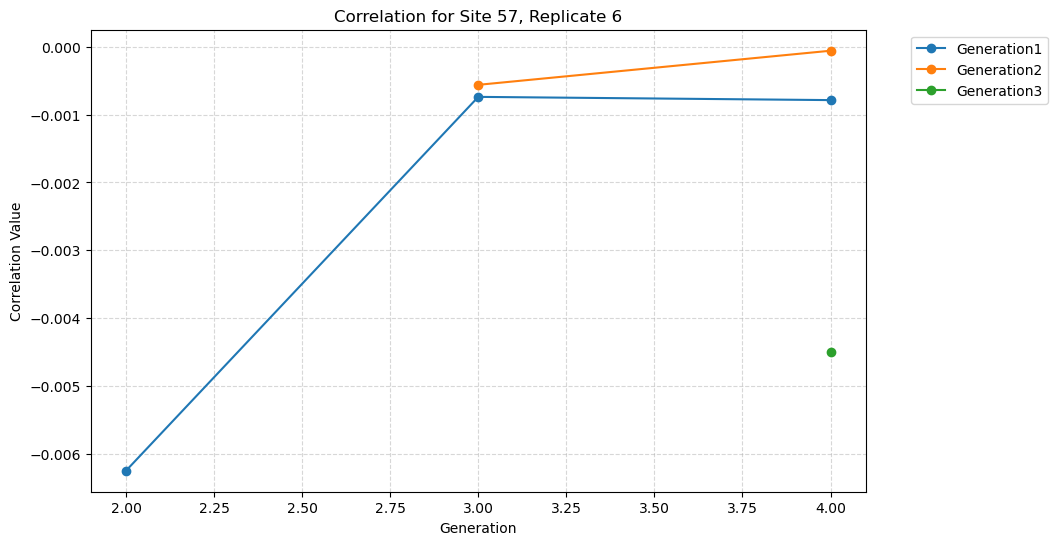

['1', '2', '3', '4', '5']
[['2', '3', '4', '5'], ['3', '4', '5'], ['4', '5'], ['5']]
x-axis labels = ['2', '3', '4', '5']
x-axis labels = ['3', '4', '5']
x-axis labels = ['4', '5']
x-axis labels = ['5']


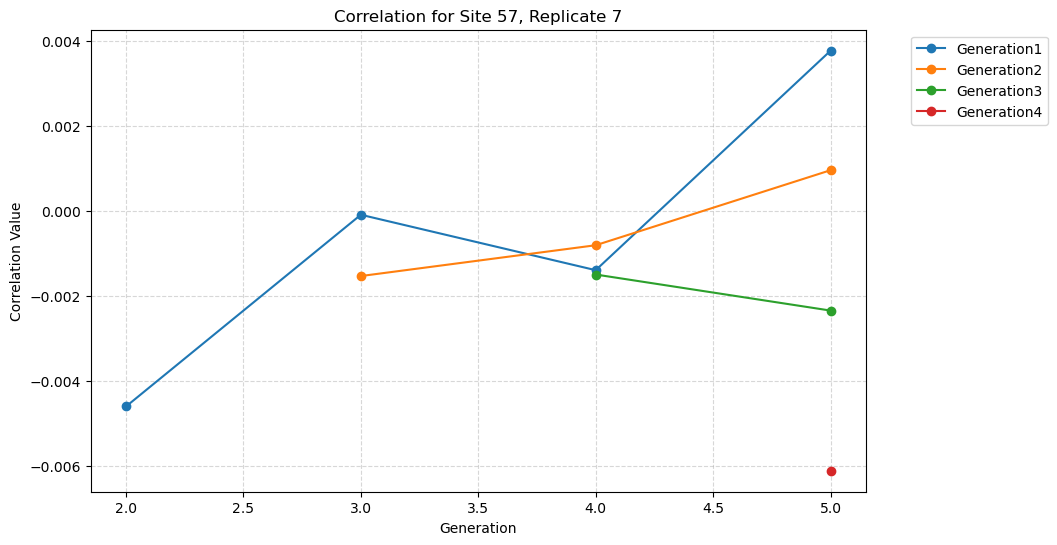

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['4']
[]


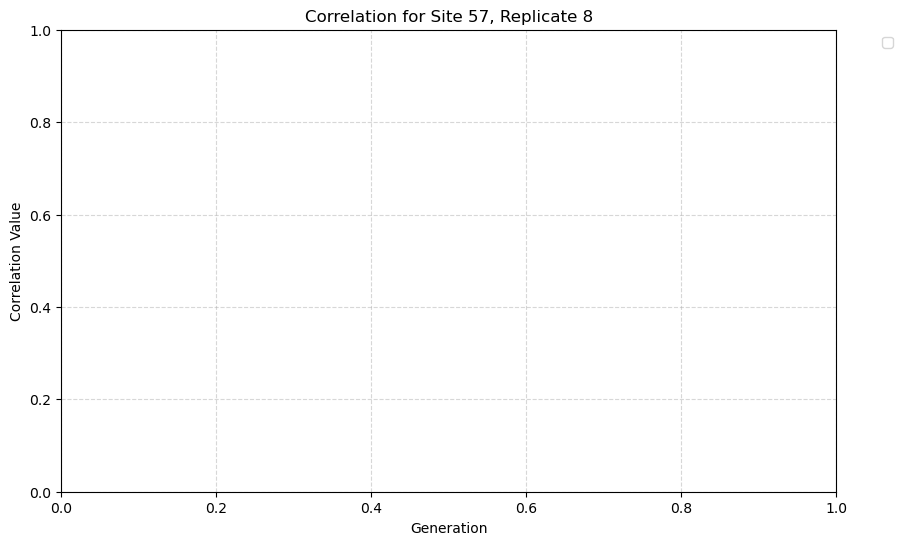

['1', '2', '3', '4', '5']
[['2', '3', '4', '5'], ['3', '4', '5'], ['4', '5'], ['5']]
x-axis labels = ['2', '3', '4', '5']
x-axis labels = ['3', '4', '5']
x-axis labels = ['4', '5']
x-axis labels = ['5']


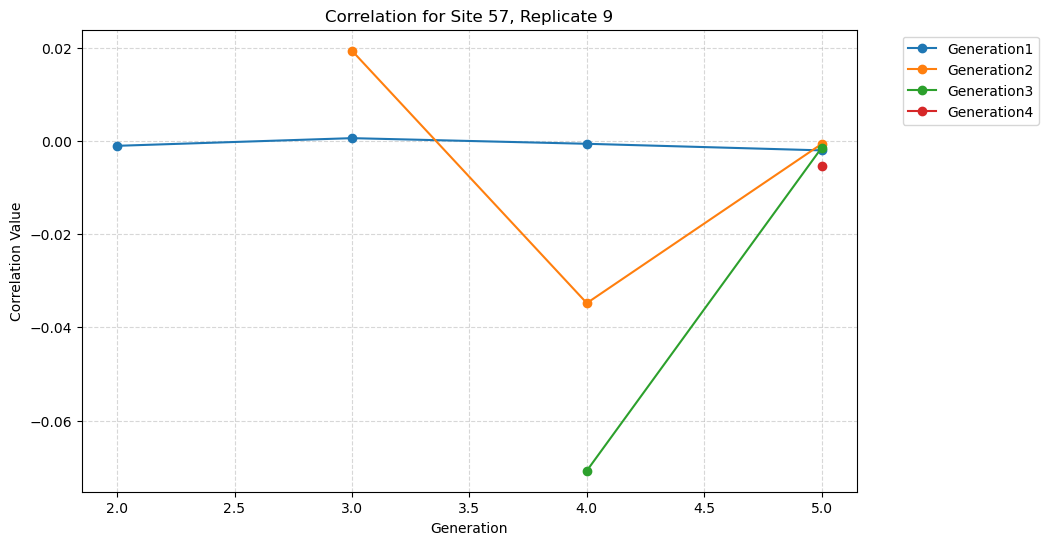

['1', '2', '3', '4', '5']
[['2', '3', '4', '5'], ['3', '4', '5'], ['4', '5'], ['5']]
x-axis labels = ['2', '3', '4', '5']
x-axis labels = ['3', '4', '5']
x-axis labels = ['4', '5']
x-axis labels = ['5']


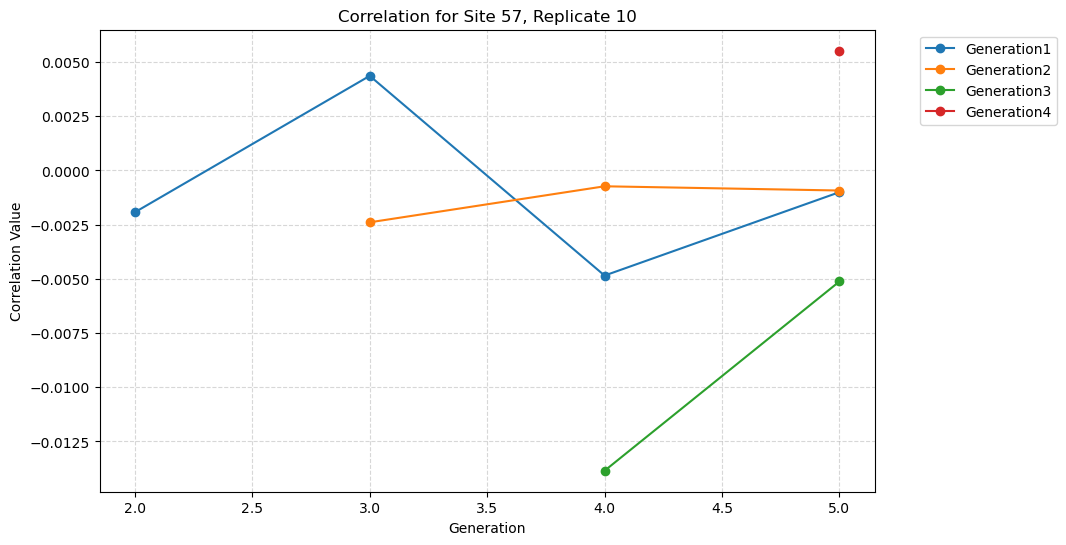

['1', '2', '3', '4']
[['2', '3', '4'], ['3', '4'], ['4']]
x-axis labels = ['2', '3', '4']
x-axis labels = ['3', '4']
x-axis labels = ['4']


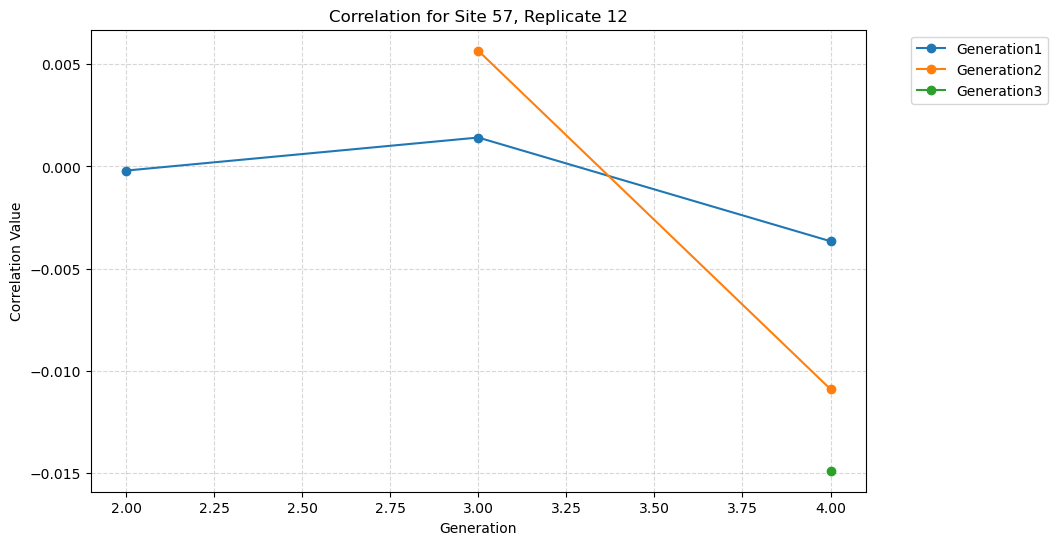

['1', '2', '3', '4', '5']
[['2', '3', '4', '5'], ['3', '4', '5'], ['4', '5'], ['5']]
x-axis labels = ['2', '3', '4', '5']
x-axis labels = ['3', '4', '5']
x-axis labels = ['4', '5']
x-axis labels = ['5']


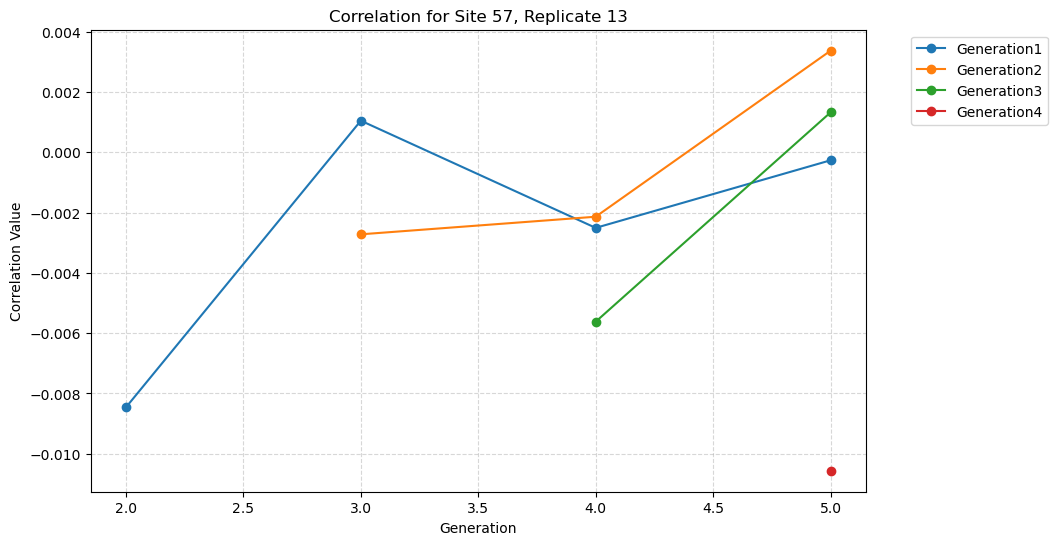

['4', '5']
[['5']]
x-axis labels = ['5']


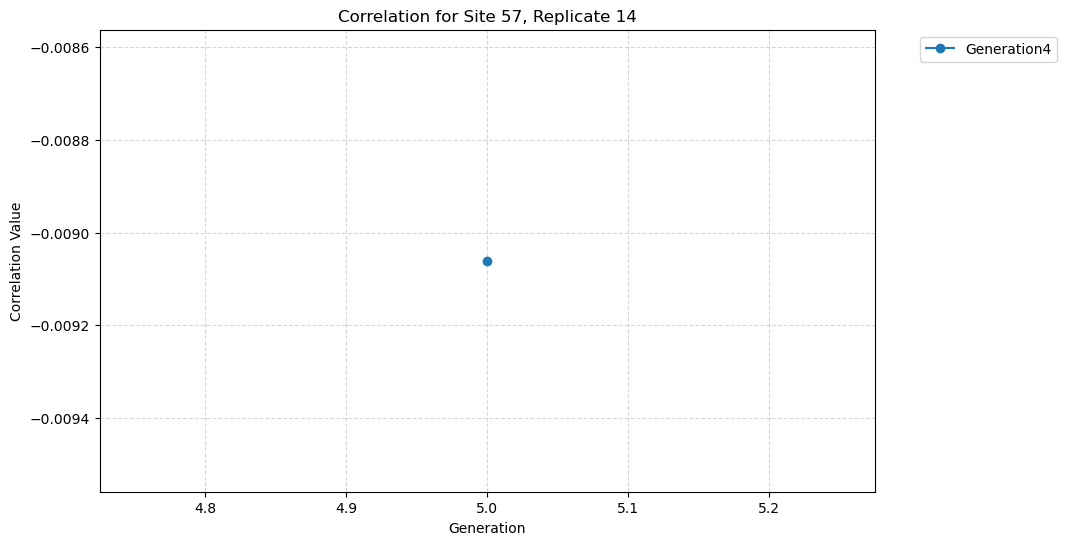

['1', '2', '3', '4']
[['2', '3', '4'], ['3', '4'], ['4']]
x-axis labels = ['2', '3', '4']
x-axis labels = ['3', '4']
x-axis labels = ['4']


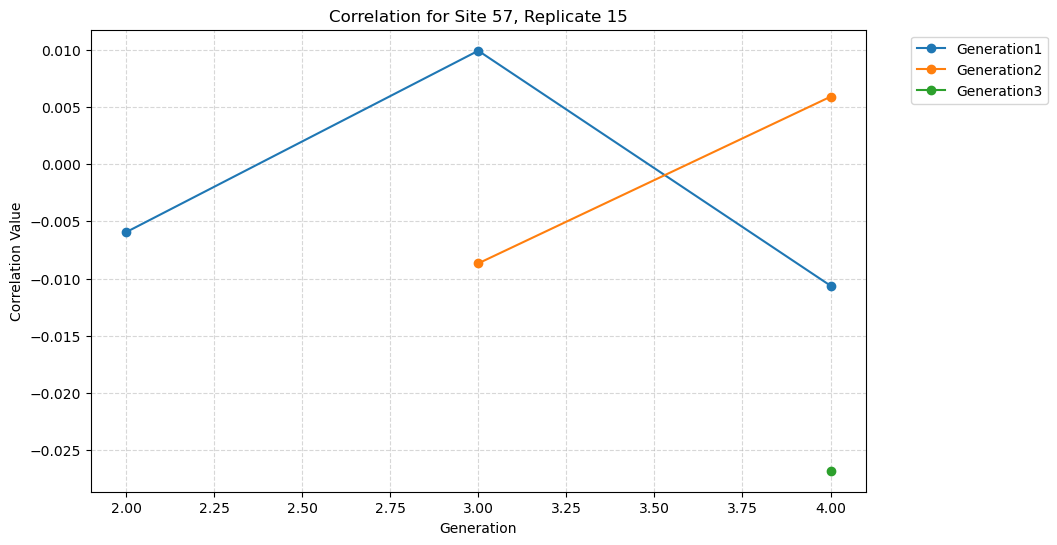

['1', '2', '3', '4', '5']
[['2', '3', '4', '5'], ['3', '4', '5'], ['4', '5'], ['5']]
x-axis labels = ['2', '3', '4', '5']
x-axis labels = ['3', '4', '5']
x-axis labels = ['4', '5']
x-axis labels = ['5']


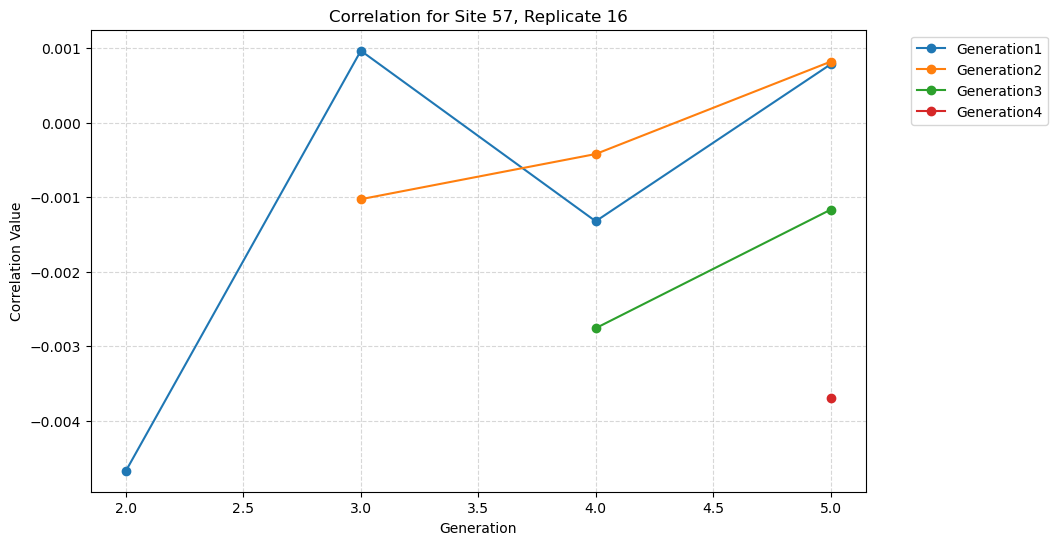

['1', '2', '3', '4', '5']
[['2', '3', '4', '5'], ['3', '4', '5'], ['4', '5'], ['5']]
x-axis labels = ['2', '3', '4', '5']
x-axis labels = ['3', '4', '5']
x-axis labels = ['4', '5']
x-axis labels = ['5']


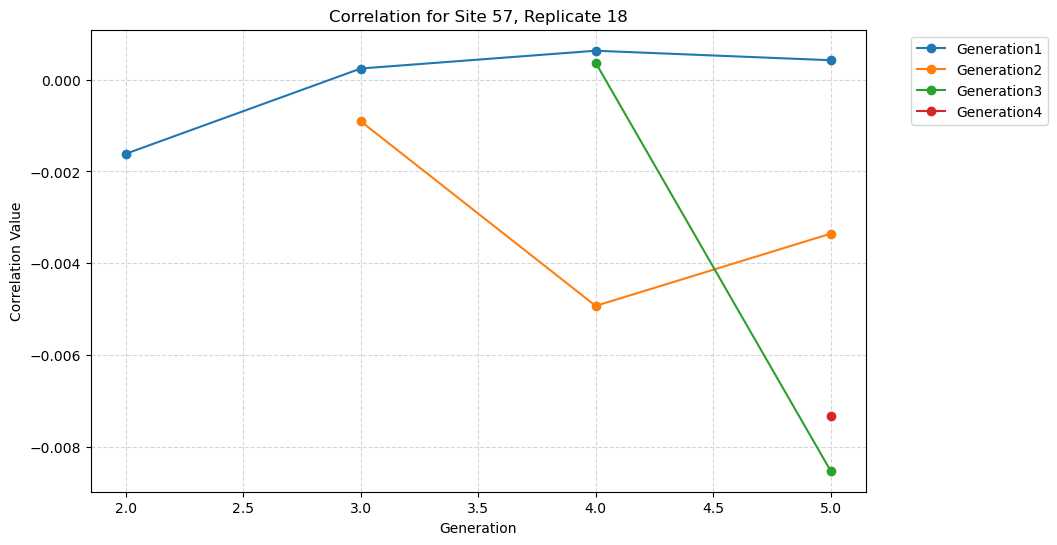

In [53]:
find_the_cov_plots_for_the_site("PHASE_1_2_COMBINED_hapFIRE_allele_frequency_random_switch_fixrm.parquet", master_df, '57')